# 📊 Data Preparation for UAV Waterfowl Detection

This notebook prepares the thermal waterfowl dataset for YOLO training.

**Steps:**
1. Load and parse CSV annotations
2. Collect positive and negative images
3. Create train/val/test splits
4. Convert annotations to YOLO format
5. Create YOLO configuration file
6. Verify the prepared dataset

## 🔧 Setup and Imports

In [15]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import pandas as pd

# Add parent directory to path
sys.path.append('../')

# Import our modules
from data.prepare_dataset import DatasetPreparer
from data import config

# Print configuration
config.print_config()

CONFIGURATION SUMMARY

Project Root: /home/code/CV_1/notebooks/..
Data Root: /home/code/CV_1/notebooks/../uav_raw

Dataset Splits:
  Train: 70.0%
  Val: 15.0%
  Test: 15.0%

Model Configuration:
  Model: yolov8n.pt
  Input Size: 640
  Epochs: 100
  Batch Size: 16
  Learning Rate: 0.001

Classes: ['waterfowl']


## 📥 Step 1: Load Annotations

Load the CSV file containing bounding box annotations.

In [16]:
preparer = DatasetPreparer()
df = preparer.load_annotations()

# Display first few rows
print("\nFirst 10 annotations:")
df.head(10)


LOADING ANNOTATIONS
✓ Loaded 8975 annotations from Bounding Box Label.csv
  Columns: ['imageFilename', 'x(column)', 'y(row)', 'width', 'height']
  Unique images: 355

  Birds per image:
    Mean: 25.28
    Median: 17.00
    Min: 1
    Max: 157

First 10 annotations:


,imageFilename,x(column),y(row),width,height
0,20180322_101536_979_R.tif,127,11,7,7
1,20180322_101536_979_R.tif,174,32,7,7
2,20180322_101536_979_R.tif,178,19,7,7
3,20180322_101536_979_R.tif,199,31,7,7
4,20180322_101536_979_R.tif,223,51,7,7
5,20180322_101536_979_R.tif,228,48,7,7
6,20180322_101536_979_R.tif,236,42,7,7
7,20180322_101536_979_R.tif,291,46,7,7
8,20180322_101536_979_R.tif,310,16,7,7
9,20180322_101536_979_R.tif,301,42,7,7


### 📊 Annotation Statistics

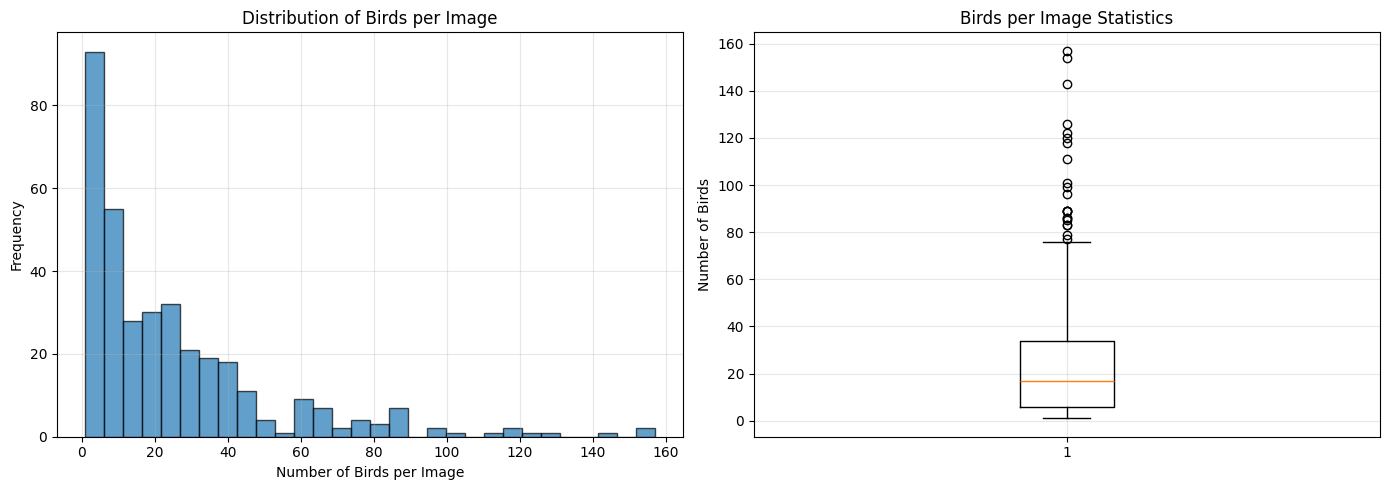

Statistics:
  Mean: 25.28
  Median: 17.00
  Std: 27.11
  Min: 1
  Max: 157


In [17]:
# Analyze distribution of birds per image
birds_per_image = df.groupby('imageFilename').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(birds_per_image, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Birds per Image')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Birds per Image')
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(birds_per_image, vert=True)
axes[1].set_ylabel('Number of Birds')
axes[1].set_title('Birds per Image Statistics')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Statistics:")
print(f"  Mean: {birds_per_image.mean():.2f}")
print(f"  Median: {birds_per_image.median():.2f}")
print(f"  Std: {birds_per_image.std():.2f}")
print(f"  Min: {birds_per_image.min()}")
print(f"  Max: {birds_per_image.max()}")

## 📁 Step 2: Collect Images


COLLECTING IMAGES
✓ Found 355 positive images
✓ Found 187 negative images

✓ Total images: 542
  Positive: 355 (65.5%)
  Negative: 187 (34.5%)


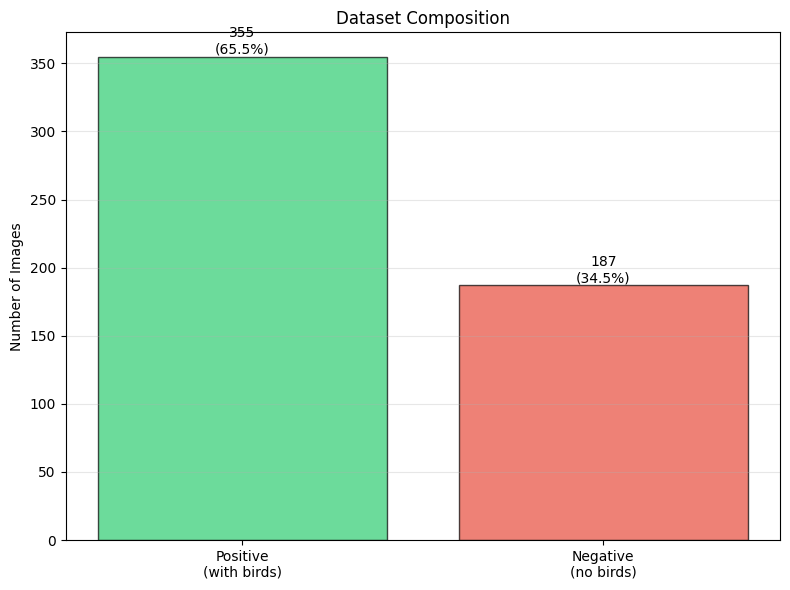

In [18]:
image_files = preparer.collect_images()

# Visualize distribution
positive_count = sum(1 for img in image_files if img['has_objects'])
negative_count = sum(1 for img in image_files if not img['has_objects'])

fig, ax = plt.subplots(figsize=(8, 6))
categories = ['Positive\n(with birds)', 'Negative\n(no birds)']
counts = [positive_count, negative_count]
colors = ['#2ecc71', '#e74c3c']

bars = ax.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Number of Images')
ax.set_title('Dataset Composition')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({count/sum(counts)*100:.1f}%)',
            ha='center', va='bottom')

plt.tight_layout()
plt.show()

### 👁️ Visualize Sample Images

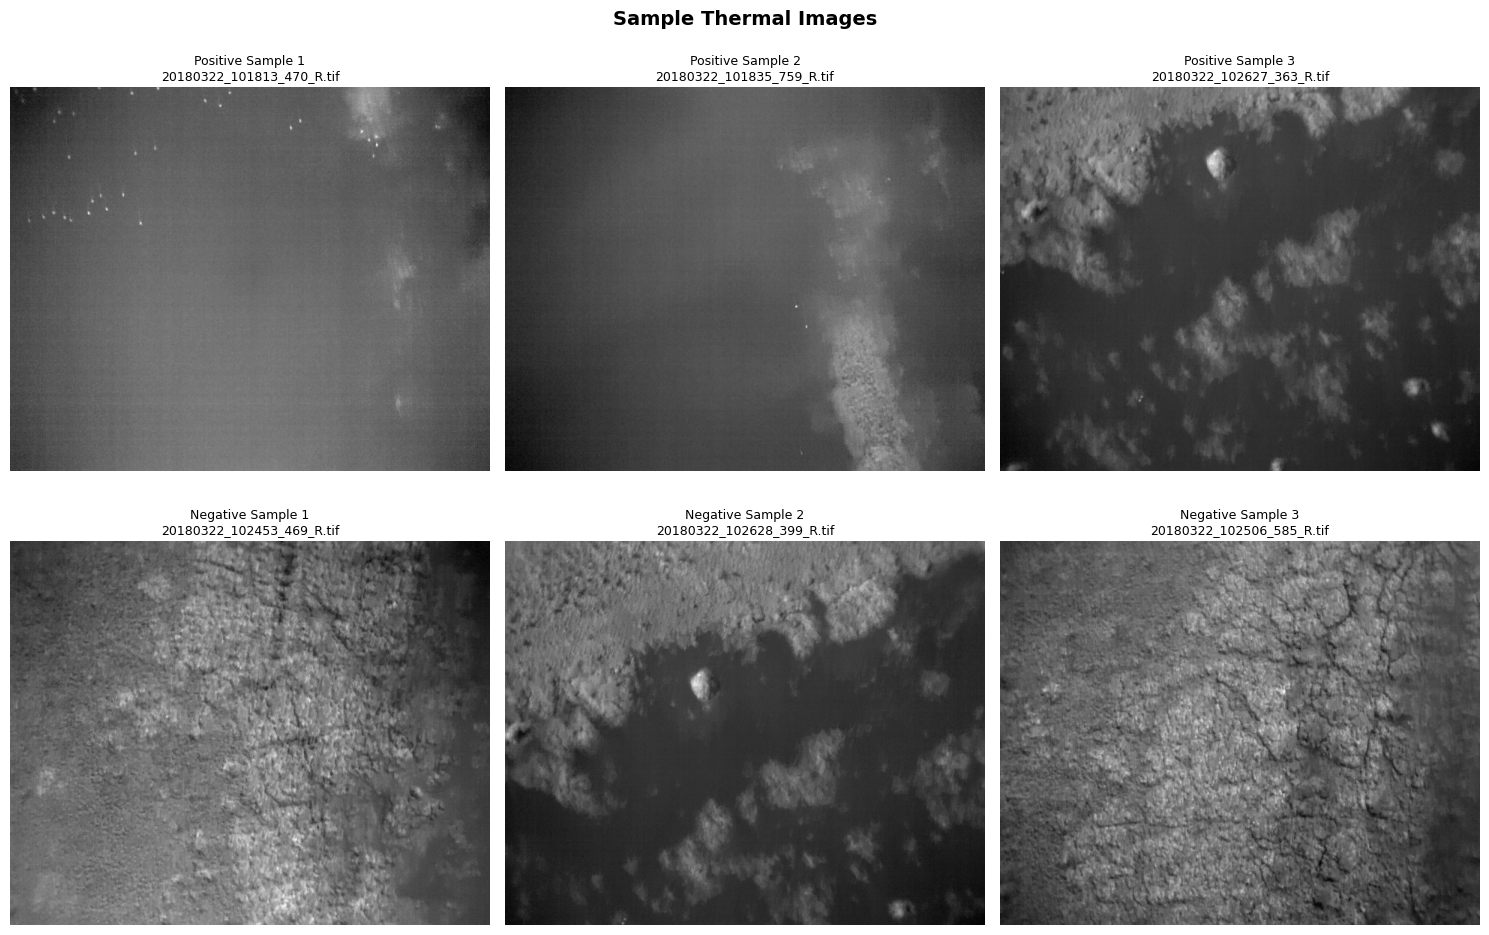

In [19]:
# Show sample positive and negative images
positive_samples = [img for img in image_files if img['has_objects']][:3]
negative_samples = [img for img in image_files if not img['has_objects']][:3]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Positive images
for i, img_info in enumerate(positive_samples):
    img = Image.open(img_info['path'])
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f"Positive Sample {i+1}\n{img_info['path'].name}", fontsize=9)
    axes[0, i].axis('off')

# Negative images
for i, img_info in enumerate(negative_samples):
    img = Image.open(img_info['path'])
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title(f"Negative Sample {i+1}\n{img_info['path'].name}", fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Sample Thermal Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ✂️ Step 3: Create Train/Val/Test Splits


CREATING DATASET SPLITS

Splitting positive images (355)...
Splitting negative images (187)...

--------------------------------------------------------------------------------
SPLIT STATISTICS
--------------------------------------------------------------------------------

TRAIN:
  Total: 378 images (69.7%)
  Positive: 248 (65.6%)
  Negative: 130 (34.4%)

VAL:
  Total: 81 images (14.9%)
  Positive: 53 (65.4%)
  Negative: 28 (34.6%)

TEST:
  Total: 83 images (15.3%)
  Positive: 54 (65.1%)
  Negative: 29 (34.9%)


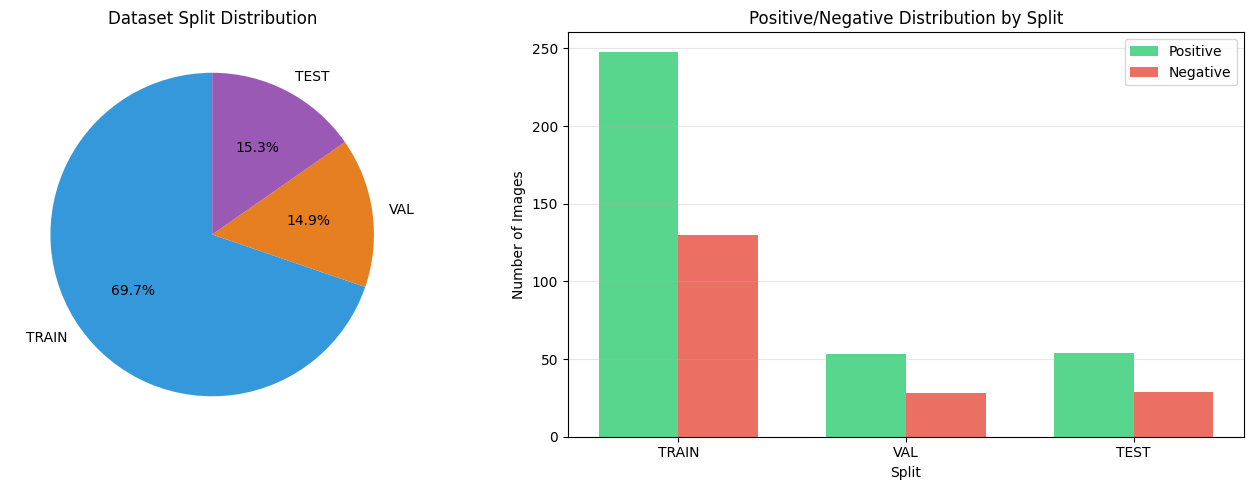

In [20]:
splits = preparer.create_splits()

# Visualize splits
split_names = list(splits.keys())
split_sizes = [len(splits[name]) for name in split_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors_pie = ['#3498db', '#e67e22', '#9b59b6']
axes[0].pie(split_sizes, labels=[s.upper() for s in split_names], autopct='%1.1f%%',
            colors=colors_pie, startangle=90)
axes[0].set_title('Dataset Split Distribution')

# Bar chart with positive/negative breakdown
x = np.arange(len(split_names))
width = 0.35

pos_counts = [sum(1 for img in splits[name] if img['has_objects']) for name in split_names]
neg_counts = [sum(1 for img in splits[name] if not img['has_objects']) for name in split_names]

bars1 = axes[1].bar(x - width/2, pos_counts, width, label='Positive', color='#2ecc71', alpha=0.8)
bars2 = axes[1].bar(x + width/2, neg_counts, width, label='Negative', color='#e74c3c', alpha=0.8)

axes[1].set_xlabel('Split')
axes[1].set_ylabel('Number of Images')
axes[1].set_title('Positive/Negative Distribution by Split')
axes[1].set_xticks(x)
axes[1].set_xticklabels([s.upper() for s in split_names])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 🔄 Step 4: Convert to YOLO Format

This will:
1. Copy images to YOLO directory structure
2. Convert CSV annotations to YOLO format (class x_center y_center width height)
3. Create label files for each image

In [21]:
# Create directories first
config.create_directories()

# Convert and copy
preparer.copy_and_convert()

✓ All directories created successfully

CONVERTING TO YOLO FORMAT

Processing train split...


  Converting train: 100%|██████████| 378/378 [00:01<00:00, 271.72it/s]


  ✓ Completed train: 378 images

Processing val split...


  Converting val: 100%|██████████| 81/81 [00:00<00:00, 302.92it/s]


  ✓ Completed val: 81 images

Processing test split...


  Converting test: 100%|██████████| 83/83 [00:00<00:00, 293.01it/s]

  ✓ Completed test: 83 images


## 📝 Step 5: Create YOLO Configuration File

In [22]:
yaml_path = preparer.create_data_yaml()

# Read and display the created YAML
with open(yaml_path, 'r') as f:
    print(f.read())


CREATING YOLO CONFIGURATION
✓ Created YOLO configuration file: /home/code/CV_1/notebooks/../processed_data/yolo_format/data.yaml

Configuration:
path: /home/code/CV_1/notebooks/../processed_data/yolo_format
train: images/train
val: images/val
test: images/test
nc: 1
names:
- waterfowl

path: /home/code/CV_1/notebooks/../processed_data/yolo_format
train: images/train
val: images/val
test: images/test
nc: 1
names:
- waterfowl



## ✅ Step 6: Verify Dataset

In [23]:
preparer.verify_dataset()


VERIFYING DATASET

TRAIN:
  Images: 378
  Labels: 378
  ✓ Match!
  Sample annotation (20180322_102042_989_R.txt): 9 objects
    First line: 0 0.171094 0.086914 0.010937 0.013672

VAL:
  Images: 81
  Labels: 81
  ✓ Match!
  Sample annotation (20180322_102420_170_R.txt): 0 objects

TEST:
  Images: 83
  Labels: 83
  ✓ Match!
  Sample annotation (20180322_101608_279_R.txt): 10 objects
    First line: 0 0.089844 0.036133 0.010937 0.013672

✓ DATASET PREPARATION COMPLETE!


## 🔍 Visualize YOLO Annotations

Let's verify the YOLO format conversion by visualizing a sample image with its bounding boxes.

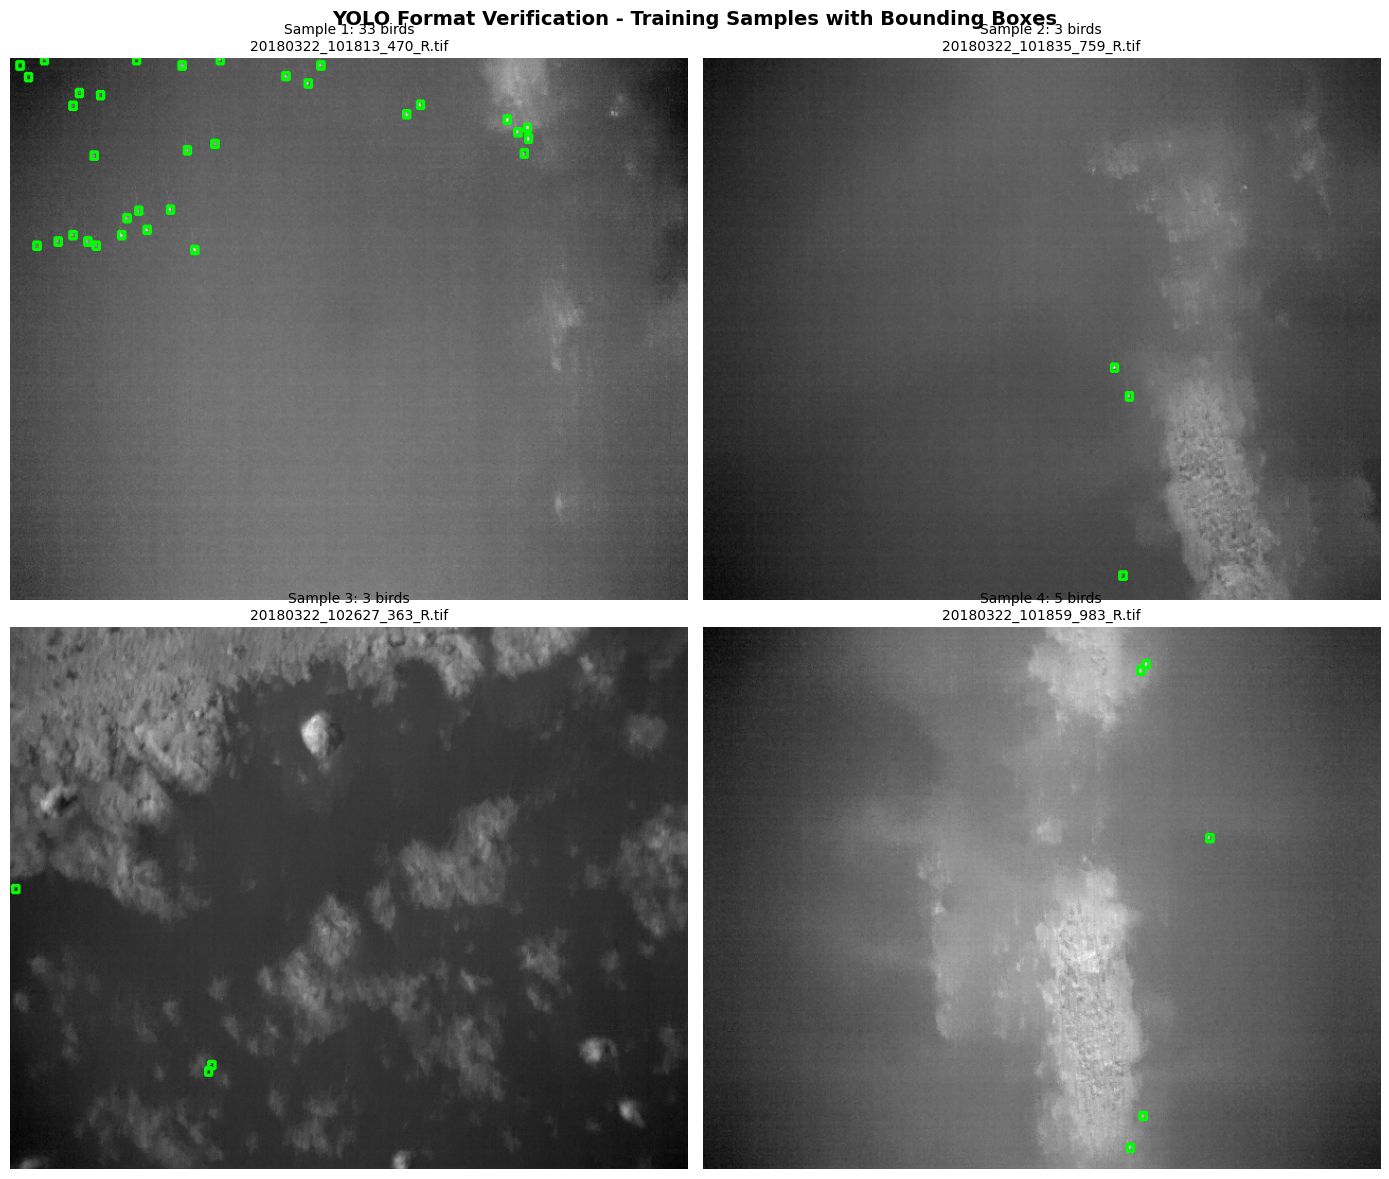

In [24]:
import cv2

def visualize_yolo_annotations(image_path, label_path):
    """Visualize YOLO format annotations on an image"""
    # Read image
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    h, w = img.shape
    
    # Read YOLO annotations
    with open(label_path, 'r') as f:
        lines = f.readlines()
    
    # Draw bounding boxes
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            class_id, x_center, y_center, width, height = map(float, parts)
            
            # Convert normalized coordinates to pixel coordinates
            x_center_px = int(x_center * w)
            y_center_px = int(y_center * h)
            width_px = int(width * w)
            height_px = int(height * h)
            
            # Calculate top-left corner
            x1 = int(x_center_px - width_px / 2)
            y1 = int(y_center_px - height_px / 2)
            x2 = int(x_center_px + width_px / 2)
            y2 = int(y_center_px + height_px / 2)
            
            # Draw rectangle
            cv2.rectangle(img_color, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    return img_color, len(lines)

# Visualize samples from train set
train_images = list((config.YOLO_IMAGES_PATH / 'train').glob('*.tif'))
train_labels = list((config.YOLO_LABELS_PATH / 'train').glob('*.txt'))

# Find images with annotations
annotated_samples = []
for img_path in train_images:
    label_path = config.YOLO_LABELS_PATH / 'train' / (img_path.stem + '.txt')
    if label_path.exists():
        with open(label_path, 'r') as f:
            if len(f.readlines()) > 0:
                annotated_samples.append((img_path, label_path))
                if len(annotated_samples) >= 4:
                    break

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (img_path, label_path) in enumerate(annotated_samples):
    img_with_boxes, num_boxes = visualize_yolo_annotations(img_path, label_path)
    axes[i].imshow(img_with_boxes)
    axes[i].set_title(f"Sample {i+1}: {num_boxes} birds\n{img_path.name}", fontsize=10)
    axes[i].axis('off')

plt.suptitle('YOLO Format Verification - Training Samples with Bounding Boxes', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Final Statistics

In [25]:
print("="*80)
print("FINAL DATASET STATISTICS")
print("="*80)

total_images = 0
total_annotations = 0

for split in ['train', 'val', 'test']:
    label_dir = config.YOLO_LABELS_PATH / split
    num_images = len(list(label_dir.glob('*.txt')))
    
    # Count total annotations
    num_annots = 0
    for label_file in label_dir.glob('*.txt'):
        with open(label_file, 'r') as f:
            num_annots += len(f.readlines())
    
    total_images += num_images
    total_annotations += num_annots
    
    print(f"\n{split.upper()}:")
    print(f"  Images: {num_images}")
    print(f"  Annotations: {num_annots}")
    print(f"  Avg annotations per image: {num_annots/num_images:.2f}")

print(f"\nTOTAL:")
print(f"  Images: {total_images}")
print(f"  Annotations: {total_annotations}")
print(f"  Avg annotations per image: {total_annotations/total_images:.2f}")

print("\n" + "="*80)
print("✓ DATA PREPARATION COMPLETE!")
print("="*80)
print(f"\n📁 Dataset location: {config.YOLO_DATASET_PATH}")
print(f"📄 Config file: {config.get_yolo_data_yaml_path()}")
print("\n🚀 Ready for model training!")

FINAL DATASET STATISTICS

TRAIN:
  Images: 378
  Annotations: 6311
  Avg annotations per image: 16.70

VAL:
  Images: 81
  Annotations: 1253
  Avg annotations per image: 15.47

TEST:
  Images: 83
  Annotations: 1411
  Avg annotations per image: 17.00

TOTAL:
  Images: 542
  Annotations: 8975
  Avg annotations per image: 16.56

✓ DATA PREPARATION COMPLETE!

📁 Dataset location: /home/code/CV_1/notebooks/../processed_data/yolo_format
📄 Config file: /home/code/CV_1/notebooks/../processed_data/yolo_format/data.yaml

🚀 Ready for model training!


---

## 🎉 Data Preparation Complete!

**Next Steps:**
1. ✅ Data is now in YOLO format
2. ⏭️ Proceed to training notebook: `02_model_training.ipynb`

**Dataset Summary:**
- Train/Val/Test splits created
- Annotations converted to YOLO format
- Configuration file generated
- Ready for YOLOv8 training!